# 분류 및 군집분석 기반 고객 이탈 예측
## Telco Customer Churn 데이터셋 — Classification & Clustering

**과목:** 데이터어낼리틱스  
**데이터셋:** Kaggle *Telco Customer Churn* (고객 7,043명 · 21개 변수 · 타겟 `Churn`)

---

### 분석 개요
본 노트북은 통신사 고객 이탈(Churn) 데이터를 활용하여 **지도학습(분류)** 과 **비지도학습(군집)** 을 함께 수행한다.

| 단계 | 내용 |
|---|---|
| **Task 1** | 데이터 탐색(EDA) · 결측/이상치 처리 · 인코딩 · 스케일링 · 학습/테스트 분리 |
| **Task 2** | Decision Tree · Naïve Bayes · KNN (+ Logistic / SVM / Random Forest / Gradient Boosting) 구축 및 성능 비교 |
| **Task 3** | K-Means 고객 세분화 · 엘보우/실루엣 · 군집 특성 분석 · 이탈 교차분석 (+ DBSCAN · 계층군집 · PCA) |
| **Task 4** | 결과 해석 및 비즈니스 인사이트 |   


---   
**지도학습 vs 비지도학습**   
**지도학습**: 정답(`Churn`)이 주어진 상태에서 이를 예측 => 분류  
**비지도학습**: 정답 없이 데이터 내부의 유사 그룹을 스스로 찾는 것 => 군집

## 0. 라이브러리 임포트 및 환경 설정

In [84]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42  # 재현성 확보를 위한 고정 시드
print('라이브러리 및 환경 설정 완료')

라이브러리 및 환경 설정 완료


## Task 1. 데이터 탐색 및 전처리

### 1-1. 데이터 로드 및 기본 정보 확인

In [85]:
# 데이터 로드
DATA_PATH = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'   # Kaggle 원본 파일명
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    url = ('https://raw.githubusercontent.com/IBM/'
           'telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
    df = pd.read_csv(url)


#shape
print('데이터 크기(shape):', df.shape)
print(f'\nColumns: {list(df.columns)}')
print()
df.head()

데이터 크기(shape): (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [86]:
# 변수 타입(dtypes) 및 결측치 개요
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [87]:
# 수치형 변수 기술통계량
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [88]:
# 결측치 확인 (TotalCharges는 공백 문자열로 들어가 있어 isnull로는 잡히지 않음)
print('명시적 결측치 개수:')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else '없음')

# TotalCharges 공백(' ') 값 탐지
blank = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print(f'\nTotalCharges 공백 값 개수: {blank}개')

명시적 결측치 개수:
없음

TotalCharges 공백 값 개수: 11개


### 1-2. 타겟 변수(Churn) 분포 확인 및 시각화

이탈 여부 분포:
  No: 5,174명 (73.5%)
  Yes: 1,869명 (26.5%)


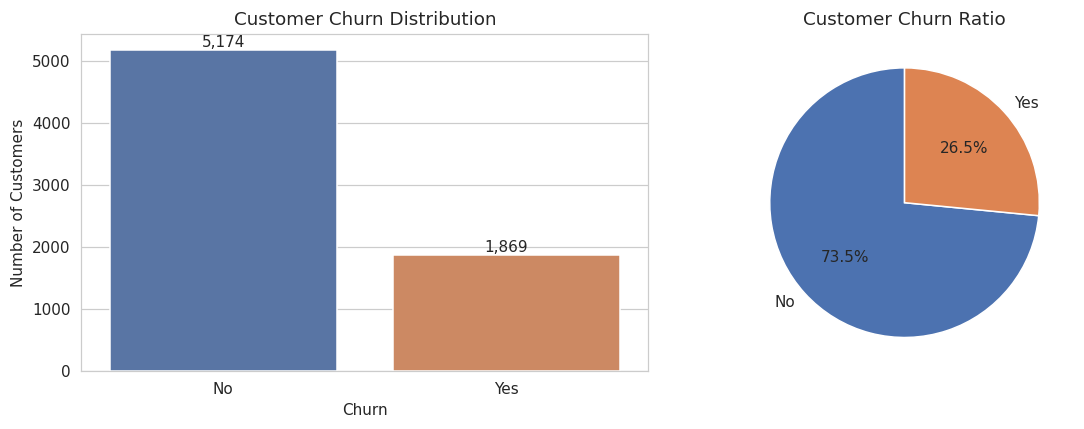

In [89]:
# 클래스 분포
#(불균형 확인)
churn_cnt = df['Churn'].value_counts()
churn_ratio = df['Churn'].value_counts(normalize=True) * 100
print('이탈 여부 분포:')
for k in churn_cnt.index:
    print(f'  {k}: {churn_cnt[k]:,}명 ({churn_ratio[k]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# (1) 막대그래프
sns.countplot(data=df, x='Churn', ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Customer Churn Distribution')
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')
# (2) 파이차트
axes[1].pie(churn_cnt, labels=churn_cnt.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Customer Churn Ratio')
plt.tight_layout(); plt.show()

약 26.5%가 이탈한 클래스 불균형 데이터이다 (No≈73.5% : Yes≈26.5%)

### 1-3. 주요 변수별 이탈/비이탈 분포 차이 시각화

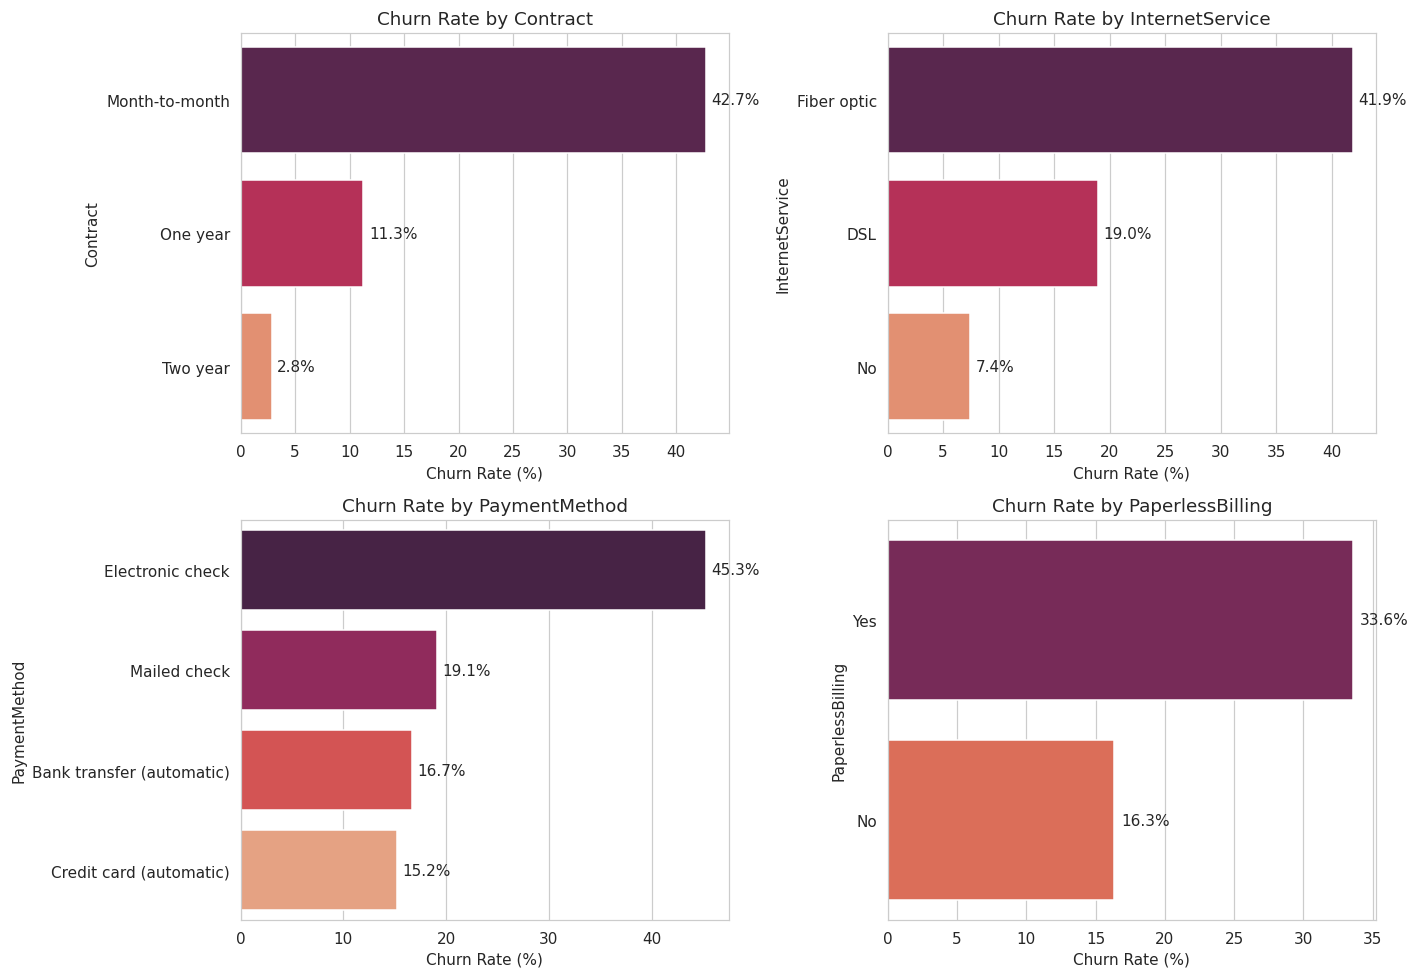

In [90]:
# (A) 범주형 변수별 이탈률 비교
cat_to_plot = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), cat_to_plot):
    # 그룹별 이탈률(%) 계산
    rate = (df.groupby(col)['Churn']
              .apply(lambda s: (s == 'Yes').mean() * 100)
              .sort_values(ascending=False))
    sns.barplot(x=rate.values, y=rate.index, ax=ax, palette='rocket')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('Churn Rate (%)'); ax.set_ylabel(col)
    for i, v in enumerate(rate.values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.tight_layout(); plt.show()

→ Month-to-month 계약, Fiber optic 인터넷, 전자수표(Electronic check) 결제 고객의 이탈률이 두드러지게 높다.

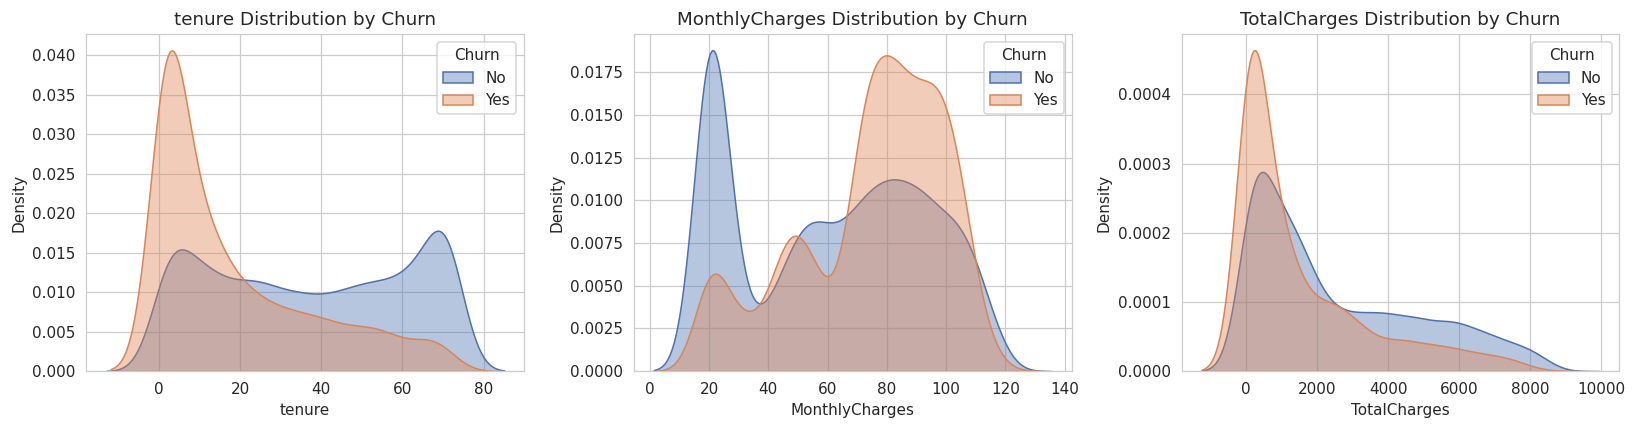

In [91]:
# (B) 연속형 변수(tenure, MonthlyCharges, TotalCharges)의 이탈 그룹별 분포
num_to_plot = ['tenure', 'MonthlyCharges', 'TotalCharges']
# TotalCharges를 일시적으로 숫자형으로 변환(시각화 용도)
tmp = df.copy()
tmp['TotalCharges'] = pd.to_numeric(tmp['TotalCharges'].astype(str).str.strip()
                                    .replace('', np.nan))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_to_plot):
    for label, color in [('No', '#4C72B0'), ('Yes', '#DD8452')]:
        sns.kdeplot(tmp.loc[tmp['Churn'] == label, col].dropna(),
                    ax=ax, fill=True, alpha=0.4, label=label, color=color)
    ax.set_title(f'{col} Distribution by Churn')
    ax.set_xlabel(col); ax.set_ylabel('Density'); ax.legend(title='Churn')
plt.tight_layout(); plt.show()

→ 가입기간(tenure)이 짧을수록 이탈이 집중되고, 월 요금(MonthlyCharges)이 높은 구간에서 이탈이 많다.

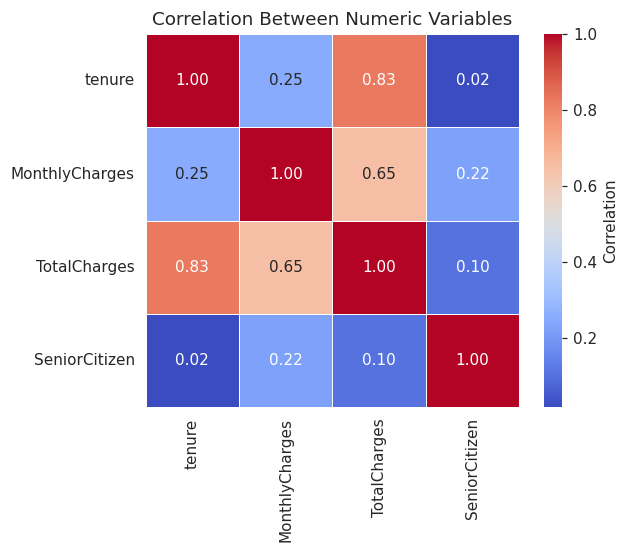

In [92]:
# (C) 수치형 변수 상관관계 히트맵
corr = tmp[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True,
            linewidths=.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Between Numeric Variables')
plt.tight_layout(); plt.show()

→ TotalCharges는 tenure·MonthlyCharges와 강한 양의 상관(가입기간×월요금의 누적)을 보인다.

### 1-4. 결측치/이상치 처리 · 인코딩 · 스케일링 · 데이터 분리

**전처리 방침**
1. `TotalCharges` 공백(11건)은 모두 **가입기간(tenure)=0인 신규 고객**이므로 누적 요금을 `0`으로 대체한다.
2. 식별자 `customerID`는 예측에 무의미하므로 제거한다.
3. 타겟 `Churn`은 `Yes→1, No→0`으로 라벨 인코딩한다.
4. 범주형 설명변수는 **원-핫 인코딩**(`drop_first=True`)으로 변환한다.
5. 연속형 변수(`tenure`, `MonthlyCharges`, `TotalCharges`)는 **StandardScaler**로 표준화한다.
6. 학습:테스트 = **80:20**, 클래스 비율을 유지하는 **층화추출(stratify)** 로 분리한다.

In [93]:
# 원본 보존을 위해 복사
data = df.copy()

# (1) TotalCharges: 공백 → NaN → 숫자형 변환
data['TotalCharges'] = pd.to_numeric(
    data['TotalCharges'].astype(str).str.strip().replace('', np.nan))

# 공백이었던 행이 정말 tenure=0인지 확인
print('TotalCharges 결측 행의 tenure 값:', data.loc[data['TotalCharges'].isna(), 'tenure'].unique())
# tenure=0(신규 가입) → 누적요금 0으로 대체
data['TotalCharges'] = data['TotalCharges'].fillna(0)
print('결측치 처리 후 남은 결측:', data['TotalCharges'].isna().sum())

# (2) 식별자 제거
data = data.drop(columns=['customerID'])

# (3) 타겟 라벨 인코딩
data['Churn'] = (data['Churn'] == 'Yes').astype(int)
print('타겟 인코딩 후 분포:', dict(data['Churn'].value_counts()))

TotalCharges 결측 행의 tenure 값: [0]
결측치 처리 후 남은 결측: 0
타겟 인코딩 후 분포: {0: np.int64(5174), 1: np.int64(1869)}


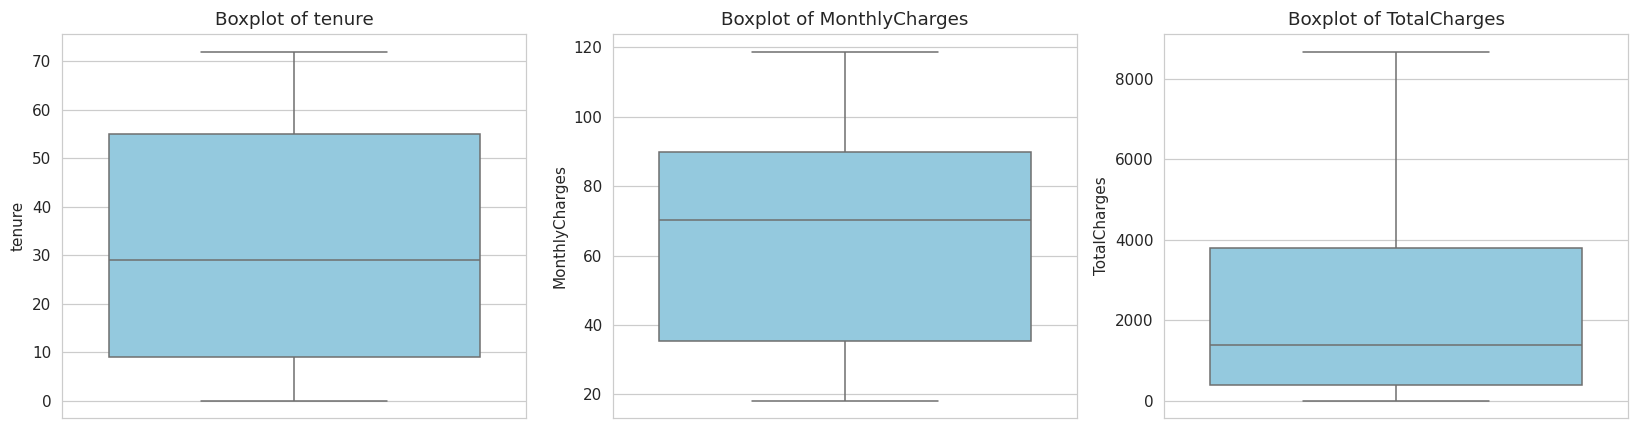

=== IQR 기반 이상치 탐지 ===
tenure: Q1=9.0, Q3=55.0, IQR=46.0, 범위=[-60.0, 124.0], 이상치 0건
MonthlyCharges: Q1=35.5, Q3=89.8, IQR=54.3, 범위=[-46.0, 171.4], 이상치 0건
TotalCharges: Q1=398.6, Q3=3786.6, IQR=3388.0, 범위=[-4683.5, 8868.7], 이상치 0건


In [94]:
# (이상치 확인) 연속형 변수 박스플롯 + IQR 기반 이상치 탐지
num_check = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 박스플롯 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_check):
    sns.boxplot(data=data, y=col, ax=ax, color='skyblue')
    ax.set_title(f'Boxplot of {col}')
    ax.set_ylabel(col)
plt.tight_layout(); plt.show()

# IQR 기반 이상치 개수 확인
print('=== IQR 기반 이상치 탐지 ===')
for col in num_check:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f'{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, '
          f'범위=[{lower:.1f}, {upper:.1f}], 이상치 {len(outliers)}건')

 3개 연속형 변수 모두 IQR 기준 이상치가 0건이므로, '
      '별도의 이상치 제거 없이 진행한다.

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# (4) 범주형 변수 원-핫 인코딩
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']          # 연속형
cat_cols = [c for c in data.columns
            if c not in num_cols + ['Churn', 'SeniorCitizen']]   # 범주형(SeniorCitizen은 이미 0/1)

data_enc = pd.get_dummies(data, columns=cat_cols, drop_first=True)
# bool → int 변환(모델 입력 통일)
bool_cols = data_enc.select_dtypes('bool').columns
data_enc[bool_cols] = data_enc[bool_cols].astype(int)

X = data_enc.drop(columns=['Churn'])
y = data_enc['Churn']
print('인코딩 후 특성 개수:', X.shape[1])

# (5) 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

#스케일링
# (6) 연속형 변수만 표준화 — train에 fit, test는 transform만(데이터 누수 방지)
scaler = StandardScaler()
X_train = X_train.copy(); X_test = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f'학습 데이터: {X_train.shape},  테스트 데이터: {X_test.shape}')
print(f'학습 이탈률: {y_train.mean():.3f}  |  테스트 이탈률: {y_test.mean():.3f}  (층화 유지 확인)')

인코딩 후 특성 개수: 30
학습 데이터: (5634, 30),  테스트 데이터: (1409, 30)
학습 이탈률: 0.265  |  테스트 이탈률: 0.265  (층화 유지 확인)


## Task 2. 분류 모델 구축 및 비교

### 2-1. 분류 모델 구축

요구된 3가지 핵심 알고리즘(**Decision Tree, Naïve Bayes, KNN**)에 더해, 추가 항목인
**Logistic Regression · SVM · Random Forest · Gradient Boosting** 까지 함께 구축하여 비교한다.

In [96]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve,
                             classification_report)

# 사용할 분류기 정의 (Decision Tree는 엔트로피=Information Gain 기준)
models = {
    'Decision Tree'      : DecisionTreeClassifier(criterion='entropy', max_depth=5,
                                                  random_state=RANDOM_STATE),
    'Naive Bayes'        : GaussianNB(),
    'KNN'                : KNeighborsClassifier(),            # K는 2-2에서 튜닝
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM'                : SVC(probability=True, random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=200,
                                                  random_state=RANDOM_STATE),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=RANDOM_STATE),
}
print('구축할 분류기:', list(models.keys()))

구축할 분류기: ['Decision Tree', 'Naive Bayes', 'KNN', 'Logistic Regression', 'SVM', 'Random Forest', 'Gradient Boosting']


# 1. KNN
#### KNN의 K값 튜닝 (거리 척도: 유클리디안)

K(이웃 수)에 따른 검증 성능 변화를 확인하여 최적 K를 선택한다.

F1-score 기준 최적 K = 29


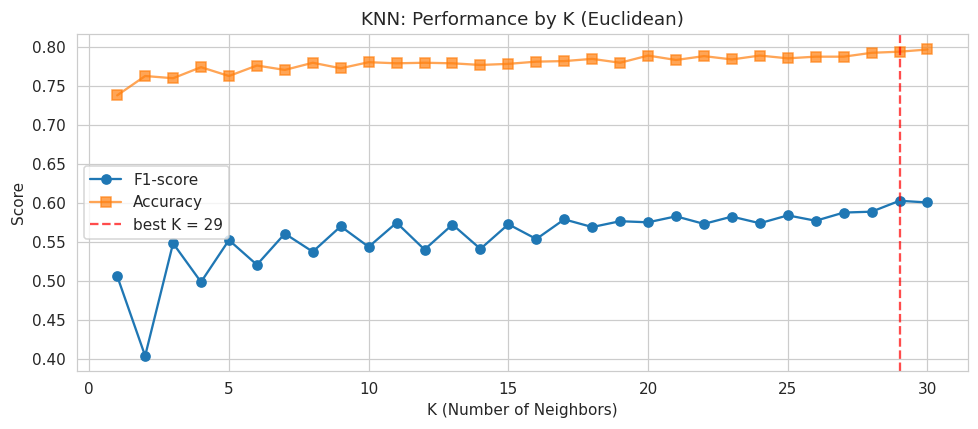

In [97]:
# K=1~30 까지 F1-score 기준으로 최적 K 탐색
k_range = range(1, 31)
k_f1, k_acc = [], []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    k_f1.append(f1_score(y_test, pred))
    k_acc.append(accuracy_score(y_test, pred))

best_k = list(k_range)[int(np.argmax(k_f1))]
print(f'F1-score 기준 최적 K = {best_k}')

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), k_f1, marker='o', label='F1-score')
plt.plot(list(k_range), k_acc, marker='s', label='Accuracy', alpha=0.7)
plt.axvline(best_k, color='red', ls='--', alpha=0.7, label=f'best K = {best_k}')
plt.title('KNN: Performance by K (Euclidean)')
plt.xlabel('K (Number of Neighbors)'); plt.ylabel('Score'); plt.legend()
plt.tight_layout(); plt.show()

# 최적 K로 KNN 갱신
models['KNN'] = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')

### 2-2. 성능 평가 — 혼동행렬 · Accuracy/Precision/Recall/F1/ROC-AUC

In [98]:
# 모든 모델 학습 및 예측 결과 저장
results = []          # 성능 표용
predictions = {}      # 혼동행렬/ROC용
proba = {}            # ROC-AUC용 확률

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    # 이탈(=1) 확률 (ROC용)
    proba[name] = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, proba[name]),
    })

result_df = pd.DataFrame(results).set_index('Model').round(4)
result_df.index.name = None
print('=== 모든 분류기 성능 종합 비교표 ===')
result_df.sort_values('F1-Score', ascending=False)

=== 모든 분류기 성능 종합 비교표 ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8062,0.6593,0.5588,0.6049,0.8422
KNN,0.7942,0.6180,0.5882,0.6027,0.8335
Naive Bayes,0.6558,0.4269,0.8663,0.5719,0.8092
Gradient Boosting,0.7977,0.6540,0.5053,0.5701,0.8415
Random Forest,0.7899,0.6291,0.5080,0.5621,0.8259
SVM,0.7949,0.6545,0.4813,0.5547,0.7948
Decision Tree,0.7921,0.6484,0.4733,0.5471,0.8273


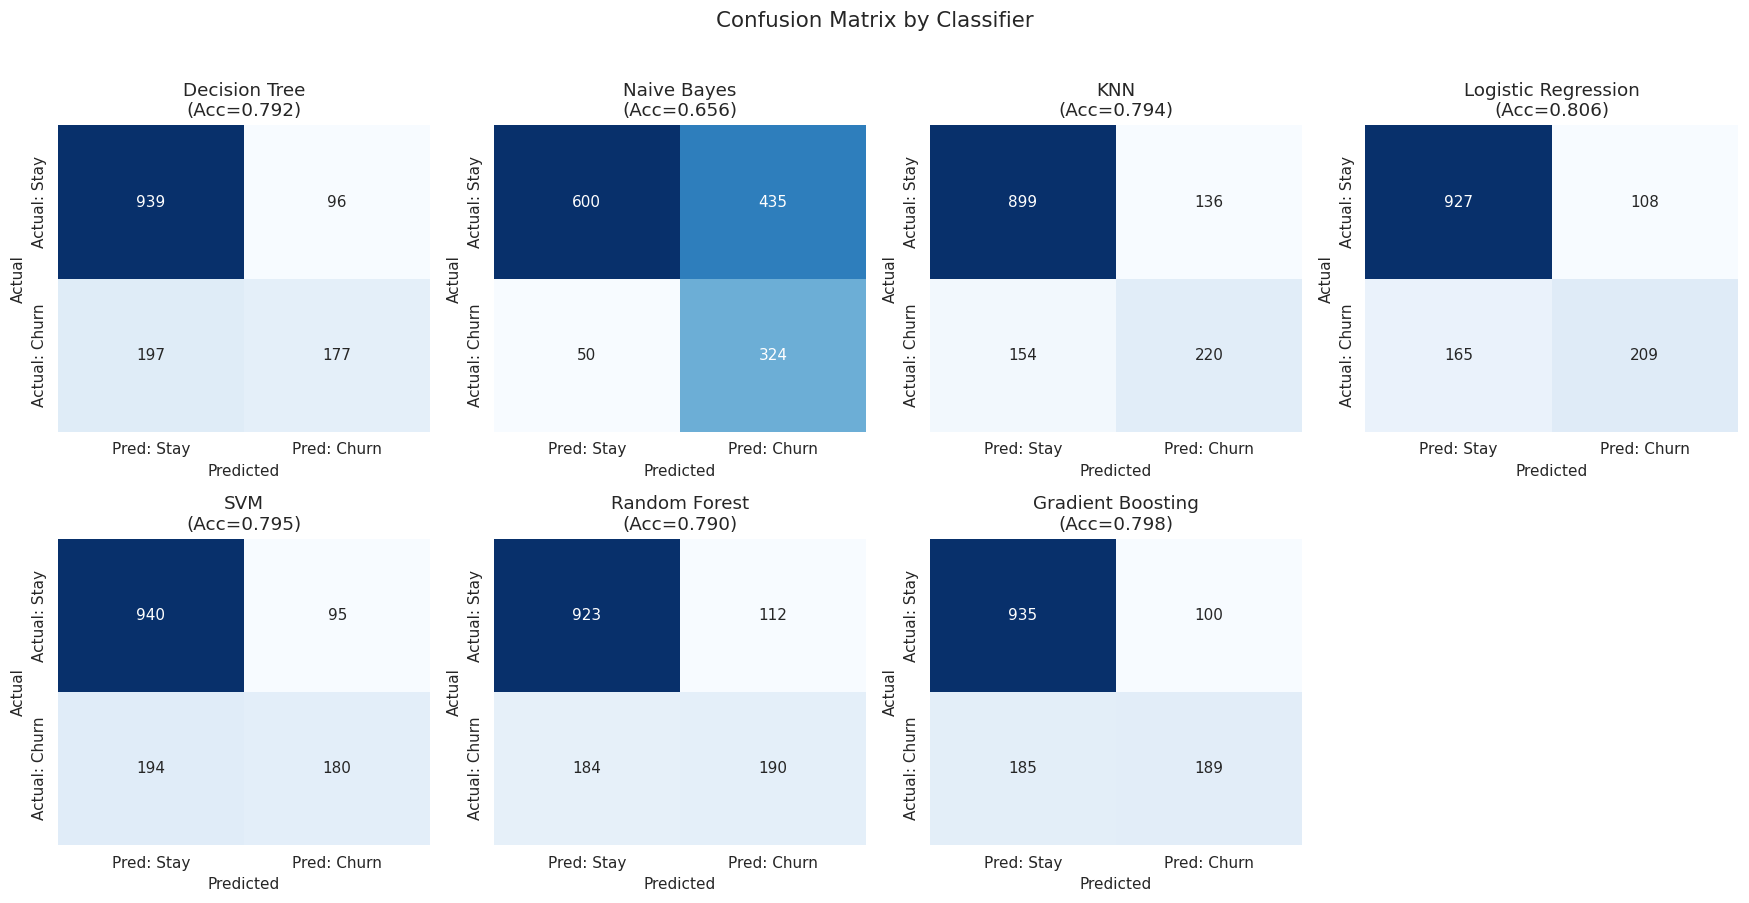

In [99]:
# 혼동행렬(Confusion Matrix) 시각화 — 모든 모델
n = len(models)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (name, y_pred) in zip(axes.flatten(), predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Pred: Stay', 'Pred: Churn'],
                yticklabels=['Actual: Stay', 'Actual: Churn'])
    ax.set_title(f'{name}\n(Acc={accuracy_score(y_test, y_pred):.3f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
# 남는 칸 숨기기
for ax in axes.flatten()[n:]:
    ax.axis('off')
plt.suptitle('Confusion Matrix by Classifier', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

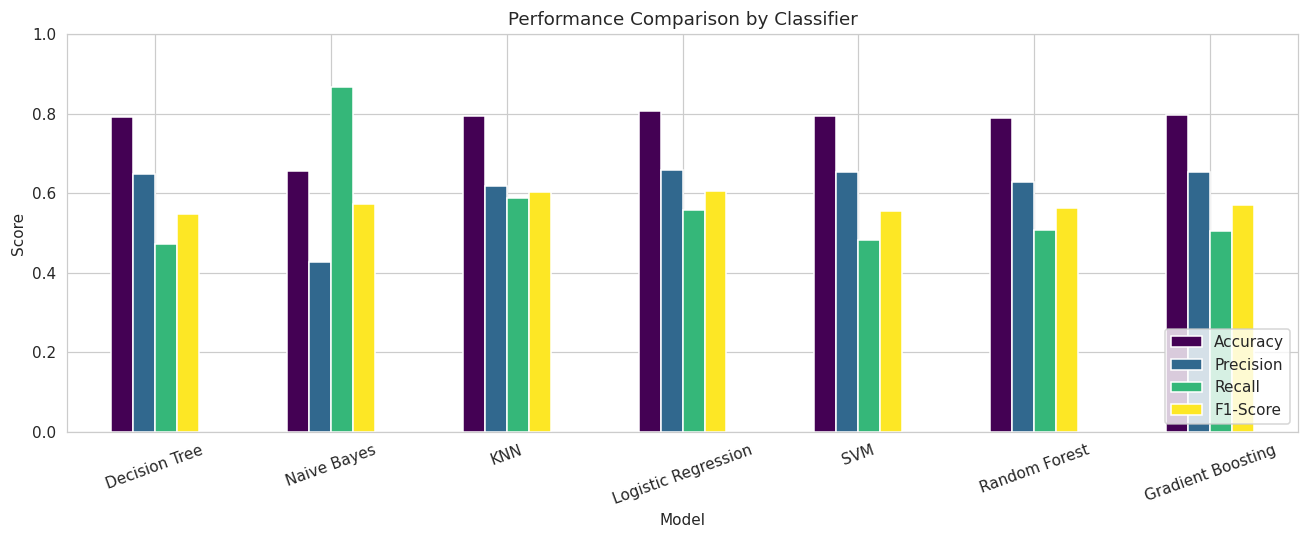

In [100]:
# 성능 지표 막대그래프 비교
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
result_df[metrics].plot(kind='bar', figsize=(12, 5), colormap='viridis')
plt.title('Performance Comparison by Classifier')
plt.xlabel('Model'); plt.ylabel('Score'); plt.xticks(rotation=20)
plt.legend(loc='lower right'); plt.ylim(0, 1)
plt.tight_layout(); plt.show()

#### (추가) ROC 곡선 및 AUC

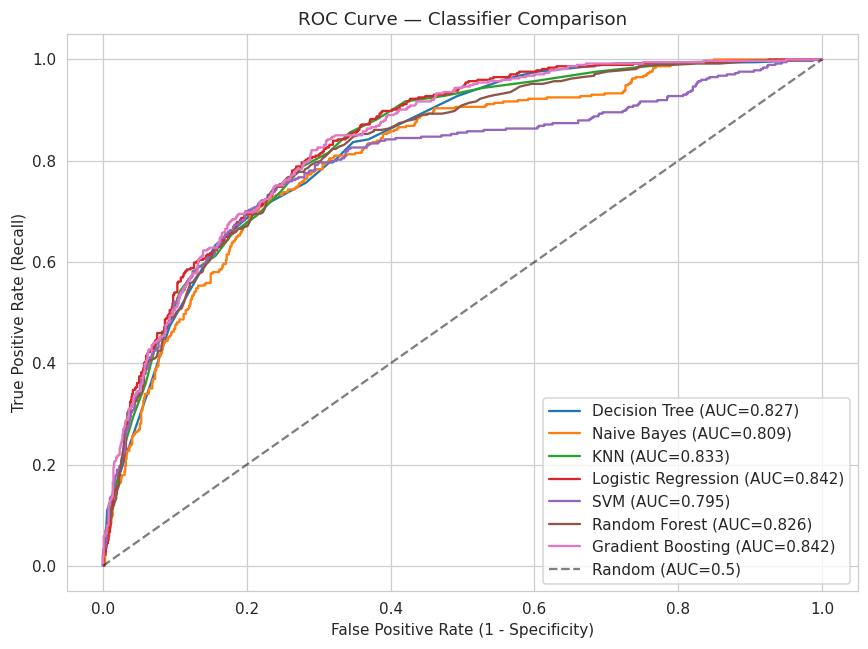

In [101]:
#ROC 곡선
plt.figure(figsize=(8, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba[name]):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
plt.title('ROC Curve — Classifier Comparison')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

### 2-3. 의사결정나무 주요 변수(feature importance) 분석

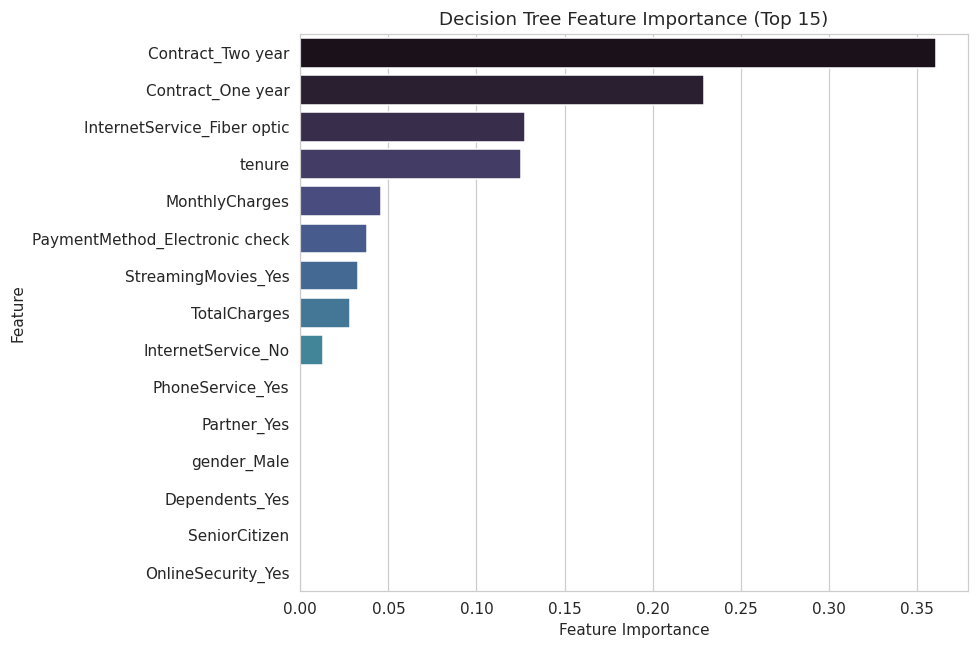

In [102]:
# 학습된 Decision Tree의 변수 중요도 상위 15개
dt = models['Decision Tree']
importances = pd.Series(dt.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top15.values, y=top15.index, palette='mako')
plt.title('Decision Tree Feature Importance (Top 15)')
plt.xlabel('Feature Importance'); plt.ylabel('Feature')
plt.tight_layout(); plt.show()

→ 이탈 예측의 핵심 동인은 계약유형(Contract), 인터넷 서비스 유형, 가입기간(tenure) 등이다.

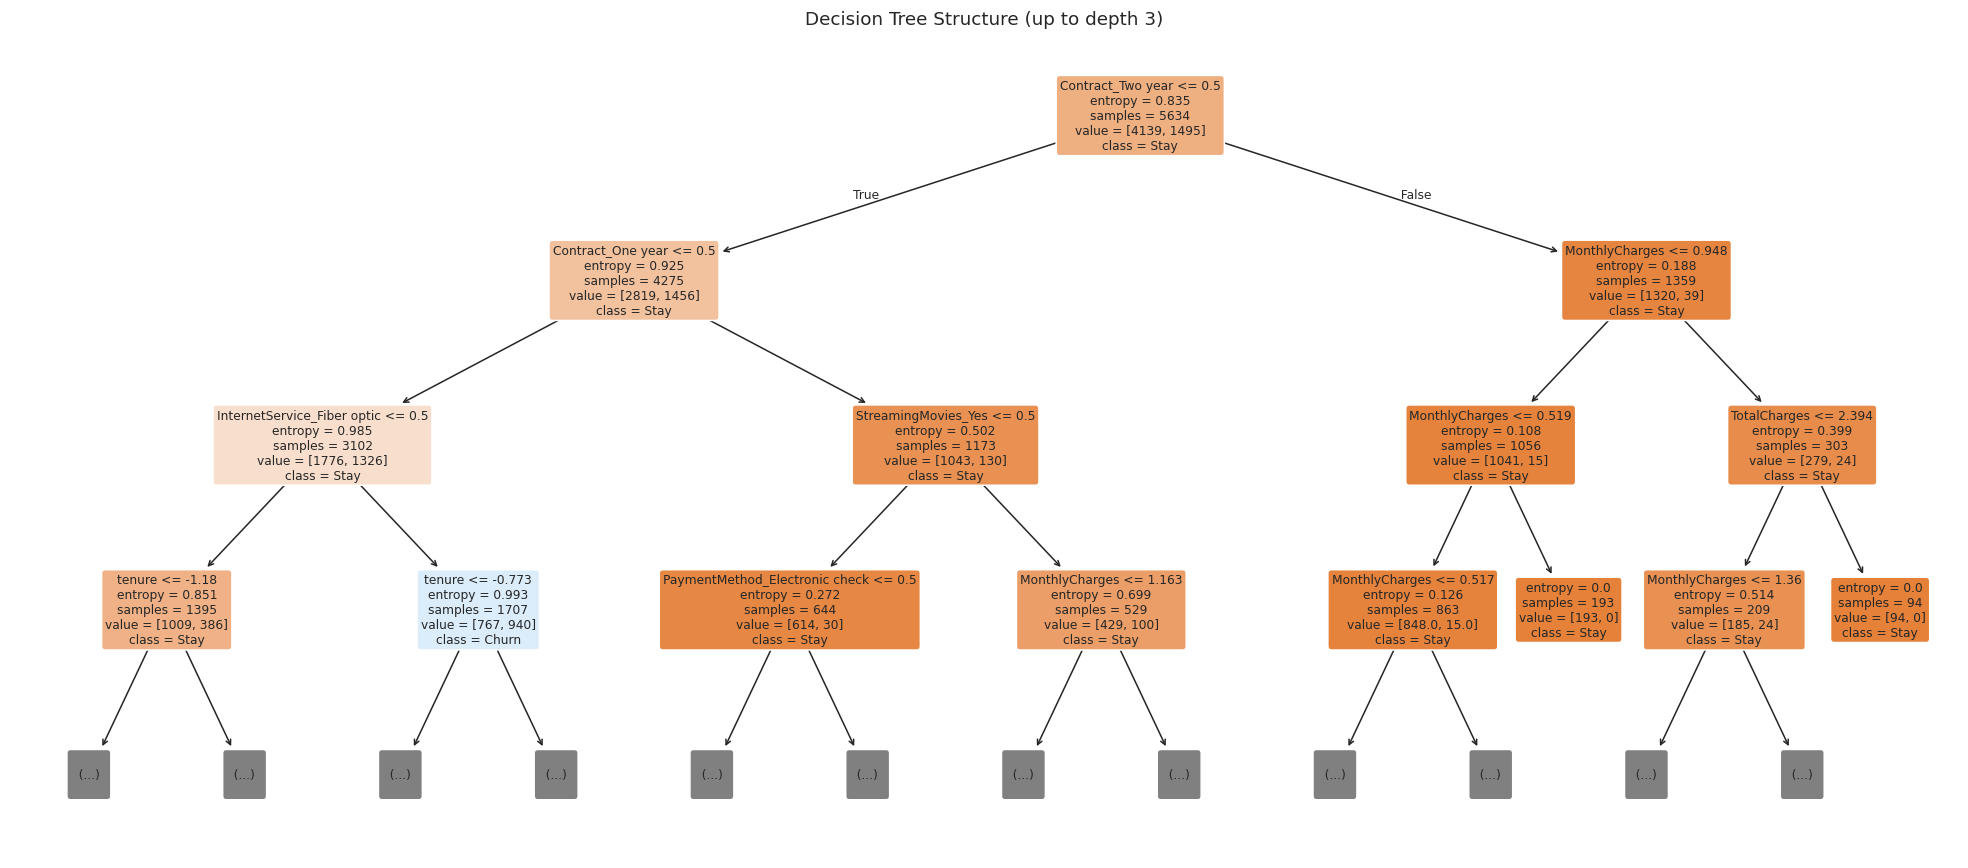

In [103]:
# (참고) 의사결정나무 구조 시각화 (상위 3단계만)
plt.figure(figsize=(18, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns,
          class_names=['Stay', 'Churn'], filled=True, fontsize=8, rounded=True)
plt.title('Decision Tree Structure (up to depth 3)')
plt.tight_layout(); plt.show()

### 2-4. Type I / Type II Error 의 비즈니스적 해석

혼동행렬에서:
- **Type I Error = FP(위양성)**: 실제로는 **유지**할 고객을 **이탈**로 잘못 예측 -> 불필요한 리텐션 마케팅 비용 발생.
- **Type II Error = FN(위음성)**: 실제로 **이탈**할 고객을 **유지**로 놓침 -> 고객 자체를 상실(획득비용·생애가치 손실).

신규 고객 획득 비용이 기존 고객 유지 비용의 5~7배라는 통념을 고려하면, **이탈 고객을 놓치는 FN(Type II)의 비용이 일반적으로 더 크다.** 따라서 본 과제에서는 단순 정확도(Accuracy)보다 **이탈 고객을 얼마나 잡아내는가**를 나타내는 **Recall(재현율)** 과 정밀도·재현율의 균형인 **F1-Score**를 핵심 지표로 삼는다.

In [104]:
# 모델별 FP(Type I) / FN(Type II) 정리
err = []
for name, y_pred in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    err.append({'Model': name, 'FP (Type I)': fp, 'FN (Type II)': fn,
                'Recall(이탈탐지율)': round(tp / (tp + fn), 3)})
err_df = pd.DataFrame(err).set_index('Model')
err_df.index.name = None
print('=== Type I / Type II 오류 및 이탈 탐지율 ===')
err_df.sort_values('FN (Type II)')

=== Type I / Type II 오류 및 이탈 탐지율 ===


,FP (Type I),FN (Type II),Recall(이탈탐지율)
Naive Bayes,435,50,0.866
KNN,136,154,0.588
Logistic Regression,108,165,0.559
Random Forest,112,184,0.508
Gradient Boosting,100,185,0.505
SVM,95,194,0.481
Decision Tree,96,197,0.473


### (추가) SMOTE를 활용한 클래스 불균형 처리

이탈 클래스(26.5%)가 소수이므로, **SMOTE**로 학습 데이터의 소수 클래스를 오버샘플링하여
재현율(Recall) 개선 효과를 확인한다. *(테스트 데이터는 원본 분포 그대로 유지하여 공정 평가)*

In [105]:
from imblearn.over_sampling import SMOTE

# 학습 데이터에만 SMOTE 적용
sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('SMOTE 적용 후 학습 분포:', dict(pd.Series(y_train_sm).value_counts()))

# 대표 모델(Logistic / Random Forest)로 SMOTE 전후 비교
smote_rows = []
for name in ['Logistic Regression', 'Random Forest']:
    base = models[name].__class__(**models[name].get_params())
    base.fit(X_train_sm, y_train_sm)
    p = base.predict(X_test)
    smote_rows.append({'Model': f'{name} + SMOTE',
                       'Accuracy': accuracy_score(y_test, p),
                       'Precision': precision_score(y_test, p),
                       'Recall': recall_score(y_test, p),
                       'F1-Score': f1_score(y_test, p)})

result_df = pd.DataFrame(results).set_index('Model').round(4)
result_df.index.name = None
print('\n=== SMOTE 적용 후 성능 (원본 결과와 비교) ===')
print('\n[원본]')
print(result_df.loc[['Logistic Regression', 'Random Forest'], metrics])
print('\n[SMOTE]')
smote_df

SMOTE 적용 후 학습 분포: {0: np.int64(4139), 1: np.int64(4139)}

=== SMOTE 적용 후 성능 (원본 결과와 비교) ===

[원본]
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8062     0.6593  0.5588    0.6049
Random Forest          0.7899     0.6291  0.5080    0.5621

[SMOTE]


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression + SMOTE,0.7615,0.5367,0.7433,0.6233
Random Forest + SMOTE,0.7715,0.5605,0.6444,0.5995


> **관찰:** SMOTE 적용 후 일반적으로 **Recall(이탈 탐지율)이 상승**하지만 Precision은 다소 하락한다.
> 이탈 고객을 놓치는 비용(FN)이 더 큰 비즈니스 맥락에서는 이 트레이드오프가 합리적인 선택일 수 있다.

## Task 3. 군집 분석 — 고객 세분화

### 3-1. K-Means 군집분석

군집에 사용할 연속형 변수로 **tenure(가입기간) · MonthlyCharges(월요금) · TotalCharges(총요금)** 를 선택하고 표준화한 뒤,
K=2~8에 대한 SSE(inertia)와 실루엣 계수를 계산하여 적정 K를 결정한다.

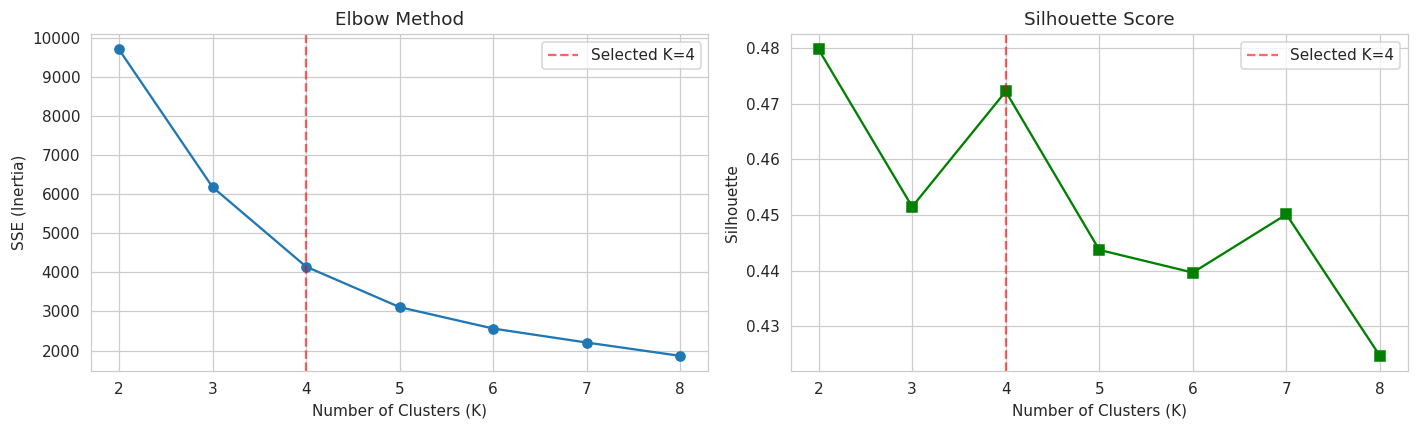

In [106]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# (1) 군집용 변수 선택 — 원본 스케일 데이터 사용
cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_cluster = data[cluster_features].copy()   # data는 TotalCharges 결측처리 완료 상태

# (2) 표준화 (군집은 거리 기반이므로 스케일링 필수)
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(df_cluster)

# (3) 엘보우 + 실루엣 계산
K_range = range(2, 9)
inertias, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)'); axes[0].set_ylabel('SSE (Inertia)')
axes[0].axvline(4, color='red', ls='--', alpha=0.6, label='Selected K=4')
axes[0].legend()
axes[1].plot(list(K_range), silhouettes, marker='s', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)'); axes[1].set_ylabel('Silhouette')
axes[1].axvline(4, color='red', ls='--', alpha=0.6, label='Selected K=4')
axes[1].legend()
plt.tight_layout(); plt.show()

→ SSE는 K=4 부근에서 꺾이고(elbow), 실루엣도 K=4에서 높은 값을 보여 K=4를 선택한다.

In [107]:
# (4) 결정된 K=4로 최종 K-Means 수행
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
data['Cluster'] = kmeans.fit_predict(X_cluster)
print(f'K={OPTIMAL_K} 군집화 완료')
print('실루엣 계수:', round(silhouette_score(X_cluster, data['Cluster']), 3))

K=4 군집화 완료
실루엣 계수: 0.472


### 3-2. 군집 결과 분석

In [108]:
# (1) 군집별 크기
size = data['Cluster'].value_counts().sort_index()
print('군집별 고객 수:')
for c in size.index:
    print(f'  Cluster {c}: {size[c]:,}명 ({size[c]/len(data)*100:.1f}%)')

# (2) 군집별 주요 변수 평균 (원본 스케일)
summary = data.groupby('Cluster')[cluster_features].mean().round(1)
summary['고객수'] = size
summary['이탈률(%)'] = (df.groupby(data['Cluster'])['Churn']
                       .apply(lambda s: (s == 'Yes').mean() * 100).round(1))

print('\n=== 군집별 특성 요약 ===')
summary

군집별 고객 수:
  Cluster 0: 1,703명 (24.2%)
  Cluster 1: 1,904명 (27.0%)
  Cluster 2: 2,276명 (32.3%)
  Cluster 3: 1,160명 (16.5%)

=== 군집별 특성 요약 ===


,tenure,MonthlyCharges,TotalCharges,고객수,이탈률(%)
Cluster,,,,,
0,10.2,31.8,302.2,1703,24.7
1,59.5,93.3,5548.7,1904,15.4
2,15.4,80.8,1251.2,2276,48.2
3,53.6,34.9,1835.6,1160,5.0


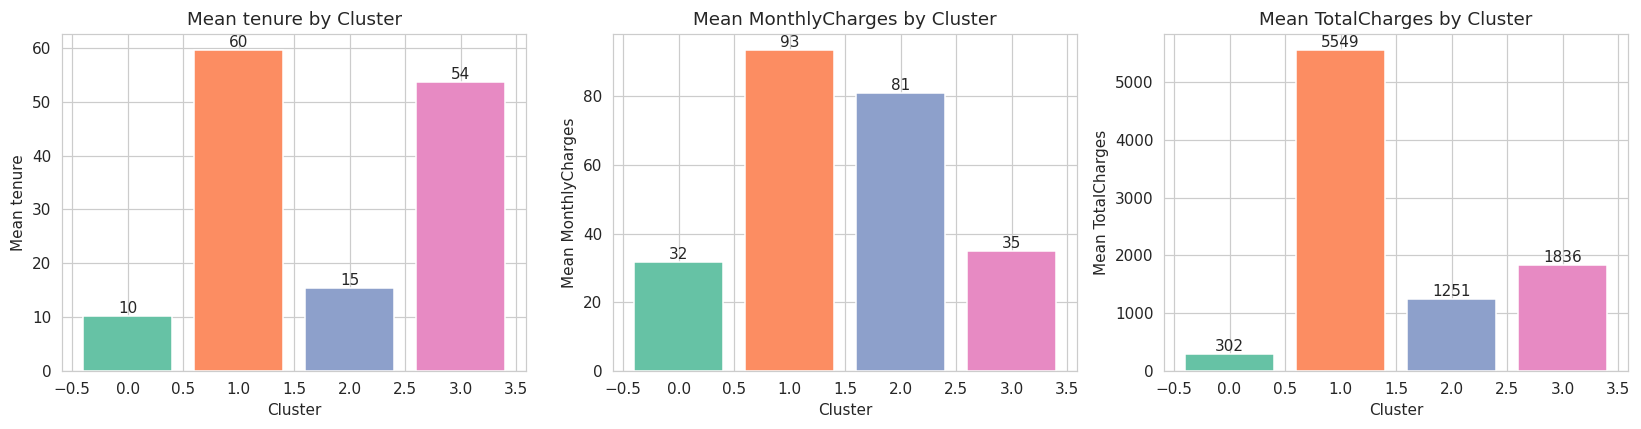

In [109]:
# (3) 군집 특성 시각화 #1 — 변수별 평균 막대그래프
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = sns.color_palette('Set2', OPTIMAL_K)
for ax, col in zip(axes, cluster_features):
    vals = data.groupby('Cluster')[col].mean()
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(f'Mean {col} by Cluster')
    ax.set_xlabel('Cluster'); ax.set_ylabel(f'Mean {col}')
    for i, v in enumerate(vals.values):
        ax.text(i, v, f'{v:.0f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

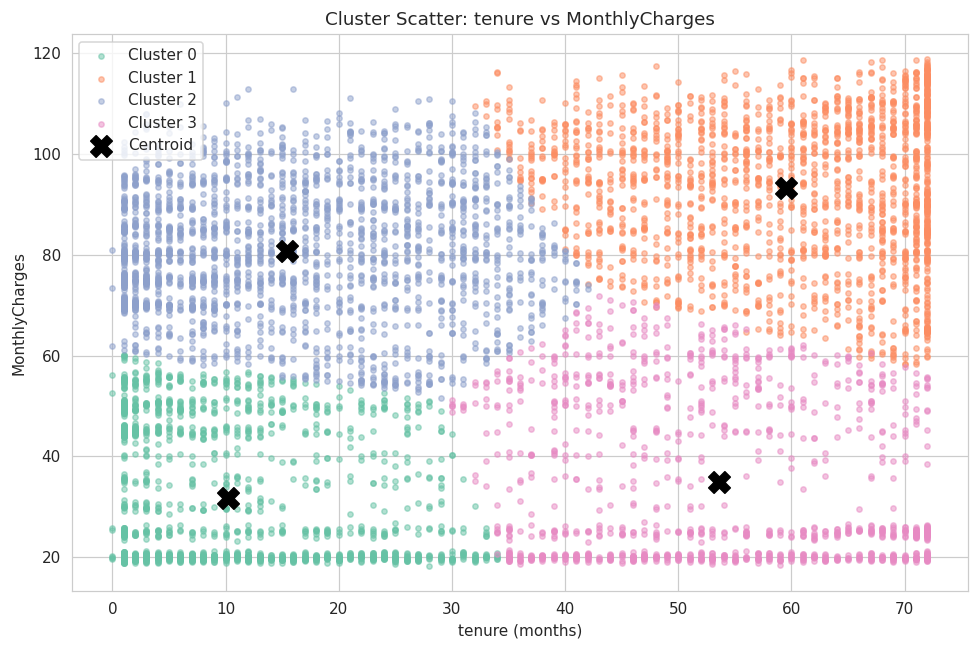

In [110]:
# (4) 군집 특성 시각화 #2 — 산점도 (tenure vs MonthlyCharges)
plt.figure(figsize=(9, 6))
for c in range(OPTIMAL_K):
    sub = data[data['Cluster'] == c]
    plt.scatter(sub['tenure'], sub['MonthlyCharges'],
                s=12, alpha=0.5, color=colors[c], label=f'Cluster {c}')
# 군집 중심 표시 (원래 스케일로 역변환)
centers = cluster_scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X',
            s=200, label='Centroid')
plt.title('Cluster Scatter: tenure vs MonthlyCharges')
plt.xlabel('tenure (months)'); plt.ylabel('MonthlyCharges')
plt.legend(); plt.tight_layout(); plt.show()

#### 군집별 비즈니스 네이밍

위 평균표·산점도를 바탕으로 각 군집에 의미를 부여한다 *(실행 결과에 따라 번호-라벨 매핑은 확인 후 조정)*:

| 군집 | 특성(가입기간 / 요금) | 비즈니스 라벨 |
|---|---|---|
| 장기·고액 | tenure 길고 TotalCharges 큼 | **충성 고액 고객 (Loyal High-Value)** |
| 장기·저액 | tenure 길고 월요금 낮음 | **안정 저관여 고객 (Stable Low-Spend)** |
| 단기·고액 | tenure 짧고 월요금 높음 | **이탈 위험 신규 고객 (At-Risk Newcomer)** |
| 단기·저액 | tenure 짧고 요금 낮음 | **탐색기 신규 고객 (New Explorer)** |

In [111]:
# 평균표 기준으로 라벨을 자동 부여 (가입기간·총요금 기준)
def name_cluster(row):
    long_tenure = row['tenure'] >= data['tenure'].median()
    high_month  = row['MonthlyCharges'] >= data['MonthlyCharges'].median()
    if long_tenure and high_month:      return '장기 고액 충성 고객'
    if long_tenure and not high_month:  return '장기 저요금 안정 고객'
    if not long_tenure and high_month:  return '신규 고요금 위험 고객'
    return '신규 저요금 고객'

cluster_names = summary.apply(name_cluster, axis=1)
data['Cluster_Name'] = data['Cluster'].map(cluster_names)
print('군집 라벨 매핑:')
for c, nm in cluster_names.items():
    print(f'  Cluster {c} → {nm}')

군집 라벨 매핑:
  Cluster 0 → 신규 저요금 고객
  Cluster 1 → 장기 고액 충성 고객
  Cluster 2 → 신규 고요금 위험 고객
  Cluster 3 → 장기 저요금 안정 고객


### 3-3. 분류–군집 교차 분석 (군집 vs 실제 이탈)

=== 군집별 이탈 교차표 ===
Churn           No   Yes  이탈률(%)
Cluster_Name                    
신규 고요금 위험 고객  1178  1098    48.2
신규 저요금 고객     1283   420    24.7
장기 고액 충성 고객   1611   293    15.4
장기 저요금 안정 고객  1102    58     5.0


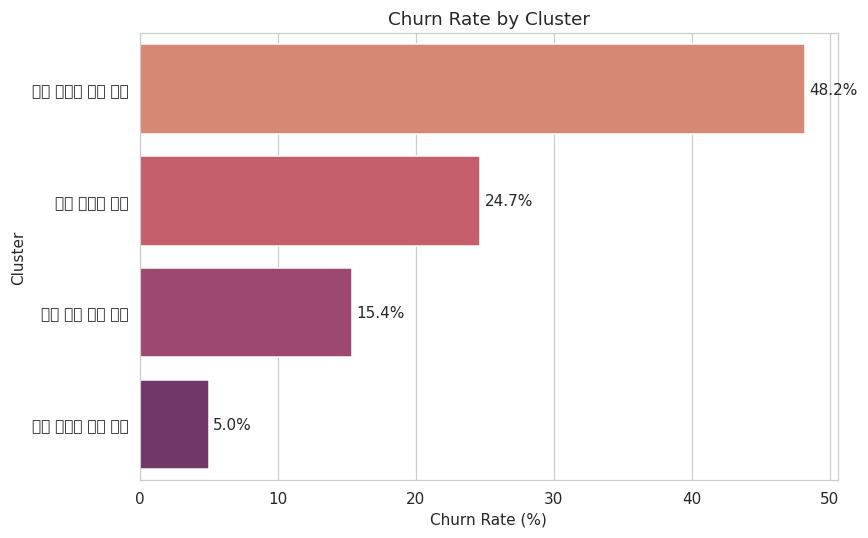

In [112]:
# 군집 × 이탈 교차표
ct = pd.crosstab(data['Cluster_Name'], df['Churn'])
ct['이탈률(%)'] = (ct['Yes'] / (ct['Yes'] + ct['No']) * 100).round(1)
print('=== 군집별 이탈 교차표 ===')
print(ct)

# 시각화
plt.figure(figsize=(8, 5))
order = ct.sort_values('이탈률(%)', ascending=False).index
sns.barplot(x=ct.loc[order, '이탈률(%)'].values, y=order, palette='flare')
plt.title('Churn Rate by Cluster')
plt.xlabel('Churn Rate (%)'); plt.ylabel('Cluster')
for i, v in enumerate(ct.loc[order, '이탈률(%)'].values):
    plt.text(v + 0.3, i, f'{v}%', va='center')
plt.tight_layout(); plt.show()


→ 가입기간이 짧은 신규 고객 군집에서 이탈률이 가장 높게 나타난다.

### (추가) PCA 2차원 시각화 · DBSCAN · 계층적 군집

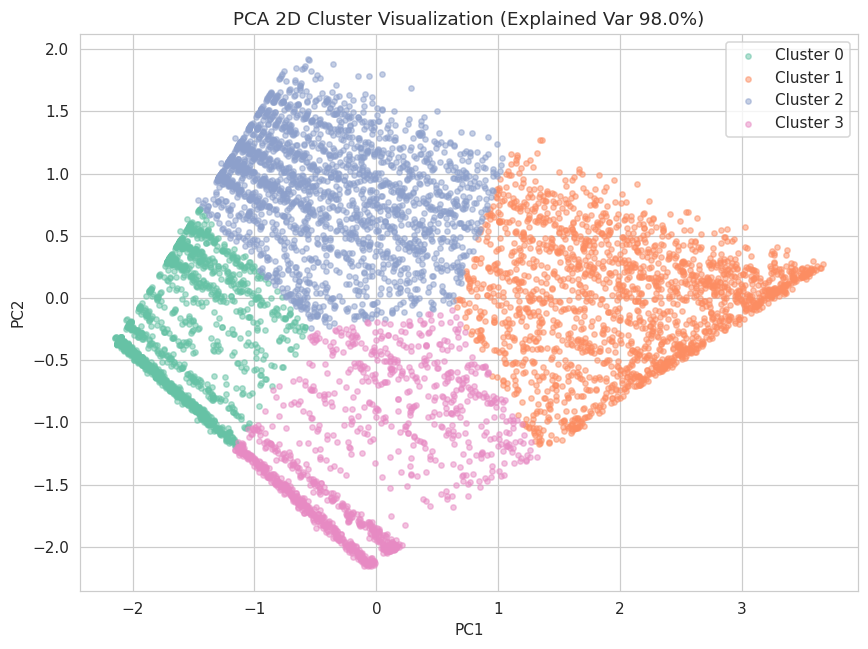

In [113]:
from sklearn.decomposition import PCA

# PCA로 3차원 → 2차원 축소 후 K-Means 군집 시각화
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
for c in range(OPTIMAL_K):
    m = data['Cluster'] == c
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=12, alpha=0.5,
                color=colors[c], label=f'Cluster {c}')
plt.title(f'PCA 2D Cluster Visualization (Explained Var {pca.explained_variance_ratio_.sum()*100:.1f}%)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.tight_layout(); plt.show()

DBSCAN: 군집 1개, 노이즈(이상치) 0개


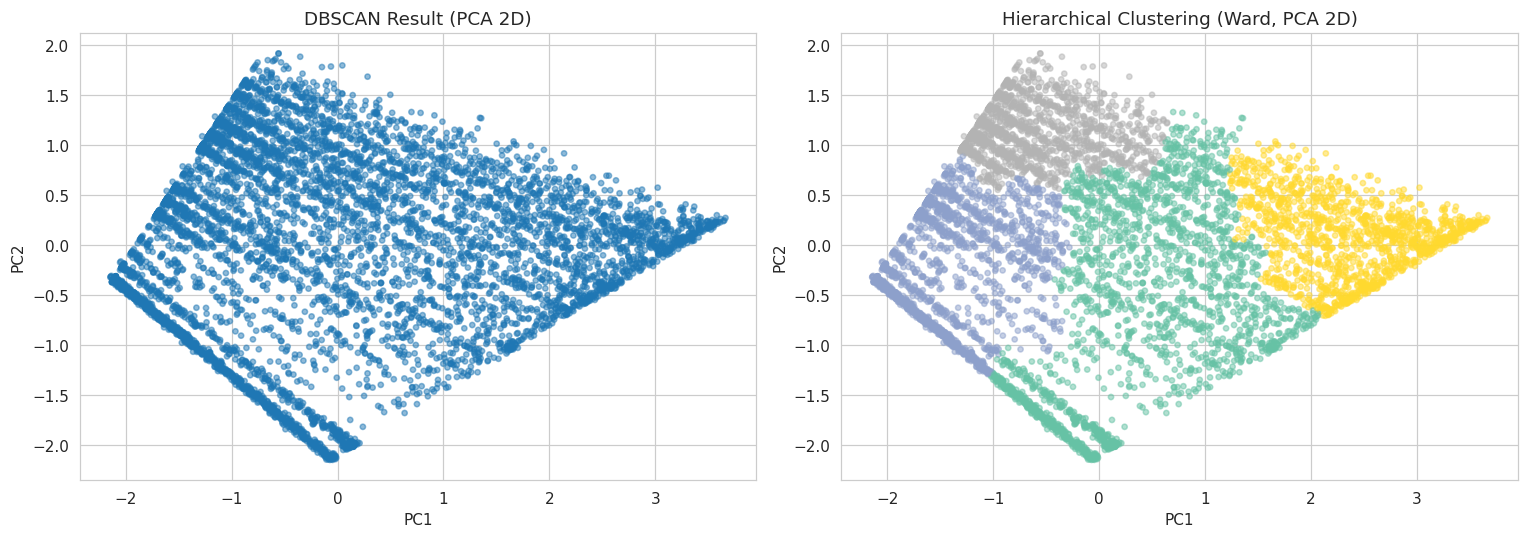

계층적 군집 vs K-Means 일치도(ARI): 0.55


In [114]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering

# DBSCAN — 밀도 기반 (이상치를 -1로 탐지)
dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels = dbscan.fit_predict(X_cluster)
n_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f'DBSCAN: 군집 {n_db}개, 노이즈(이상치) {(db_labels == -1).sum()}개')

# 계층적 군집 (Ward 연결)
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab10', s=12, alpha=0.5)
axes[0].set_title(f'DBSCAN Result (PCA 2D)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='Set2', s=12, alpha=0.5)
axes[1].set_title('Hierarchical Clustering (Ward, PCA 2D)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout(); plt.show()

print(f'계층적 군집 vs K-Means 일치도(ARI): ', end='')
from sklearn.metrics import adjusted_rand_score
print(round(adjusted_rand_score(data['Cluster'], agg_labels), 3))

## Task 4. 결과 해석 및 비즈니스 인사이트


### 1) 분류 분석 — 이탈 가능성이 높은 고객 프로필
- **계약유형(Contract):** `Month-to-month`(월 단위 계약) 고객의 이탈률이 압도적으로 높다 → 장기 약정이 없을수록 이탈.
- **가입기간(tenure):** 가입 초기(짧은 tenure) 고객이 이탈에 집중 → "초기 이탈" 패턴.
- **인터넷 서비스(InternetService):** `Fiber optic` 가입 고객의 이탈률이 높다(요금/품질 불만 가능성).
- **결제수단(PaymentMethod):** `Electronic check` 사용 고객의 이탈률이 높다.
- 의사결정나무 변수중요도와 ROC-AUC 종합 시, ROC-AUC 종합 시 로지스틱 회귀와 그래디언트 부스팅이 0.842로 가장 높은 판별력을 보인다

### 2) 군집 분석 — 군집별 차별화 전략
- C2 신규 고요금 위험 고객(단기·고액): 가입 초기 온보딩 강화, 첫 3~6개월 할인·번들로 조기 이탈 방어
- C1 장기 고액 충성 고객(장기·고액): 멤버십·우선 기술지원 로열티 프로그램, 업셀링 타겟
- C0 신규 저요금 고객(단기·저액): 장기 약정 전환 유도로 계약 리스크 완화

### 3) 종합 고객 유지(Retention) 전략 제언
분류 모델로 **이탈 확률이 높은 개별 고객을 스코어링**하고, 군집 분석으로 **고객을 세그먼트화**한 뒤,
세그먼트별로 차별화된 리텐션 액션(가격·계약·서비스)을 매칭하는 **2단계 타겟 마케팅**을 제안한다.
특히 비용 관점에서 FN(이탈 고객 놓침)이 더 크므로, **Recall을 높인 모델(+SMOTE)** 로 위험 고객을 폭넓게 포착한다.

### 4) 한계점 및 향후 개선 방향
- **클래스 불균형:** 본 분석은 SMOTE를 시도했으나, 비용 민감 학습(class_weight)·앙상블 추가 튜닝 여지가 있다.
- **모델 고도화:** XGBoost/LightGBM, 하이퍼파라미터 최적화(GridSearch), 교차검증 기반 평가 강화.
- **데이터 한계:** 고객 행동·민원·이용 로그 등 시계열·행동 데이터 추가 시 예측력 향상 기대.
- **군집 안정성:** K-Means는 초기값·구형 가정에 민감 → DBSCAN·GMM 등과 교차검증 필요.

In [115]:
# 최종 요약 출력
print('=' * 55)
print('  분석 요약')
print('=' * 55)
print(f'· 전체 고객 수      : {len(df):,}명')
print(f'· 실제 이탈률       : {(df["Churn"]=="Yes").mean()*100:.1f}%')
best = result_df["F1-Score"].idxmax()
print(f'· 최고 성능 모델    : {best} (F1={result_df.loc[best,"F1-Score"]:.3f}, '
      f'AUC={result_df.loc[best,"ROC-AUC"]:.3f})')
print(f'· 군집 수(K)        : {OPTIMAL_K}')
high = ct["이탈률(%)"].idxmax()
print(f'· 최고 이탈 군집    : {high} ({ct.loc[high,"이탈률(%)"]}%)')
print('=' * 55)

  분석 요약
· 전체 고객 수      : 7,043명
· 실제 이탈률       : 26.5%
· 최고 성능 모델    : Logistic Regression (F1=0.605, AUC=0.842)
· 군집 수(K)        : 4
· 최고 이탈 군집    : 신규 고요금 위험 고객 (48.2%)
